
# Detección “tipo objeto” en MNIST: dibujar un rectángulo (bounding box) alrededor del dígito

Dos ejemplos para clase:

1. **Detección clásica (sin DL):** umbral + bounding box por píxeles activos.
2. **Detección con DL (toy):** creamos un dataset sintético colocando dígitos MNIST en un canvas 64×64 y entrenamos una CNN que predice:
   - **Clase** (0–9)
   - **Bounding box** `(x_min, y_min, x_max, y_max)`

> El MNIST original suele estar centrado; el ejemplo 2 hace la tarea más realista.


## 0) Setup

In [1]:

# !pip -q install tensorflow matplotlib

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

SEED = 42
tf.keras.utils.set_random_seed(SEED)


2026-03-13 15:14:14.077895: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 15:14:14.372708: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-13 15:14:14.372730: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-03-13 15:14:14.417165: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-13 15:14:15.208382: W tensorflow/stream_executor/platform/de

TF: 2.10.0
GPUs: []


2026-03-13 15:14:16.586733: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-13 15:14:16.587263: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-13 15:14:16.587451: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-03-13 15:14:16.587523: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-03-13 15:14:16.587592: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

## 1) Cargar MNIST

In [2]:

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)


Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)



## 2) Ejemplo 1 — Bounding box “clásico” (umbral + píxeles activos)

**Qué haremos:** detectaremos el dígito como el conjunto de píxeles “encendidos” y sacaremos el rectángulo mínimo que lo contiene.


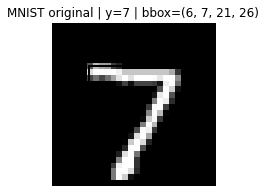

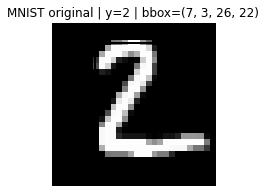

In [3]:

def bbox_from_threshold(img, thr=0.2):
    # Devuelve bbox (x_min, y_min, x_max, y_max) a partir de umbral
    mask = img > thr
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    return int(x_min), int(y_min), int(x_max), int(y_max)

def plot_img_with_bbox(img, bbox, title=None):
    plt.figure(figsize=(3,3))
    plt.imshow(img, cmap="gray")
    if bbox is not None:
        x0, y0, x1, y1 = bbox
        rect = plt.Rectangle((x0, y0), x1-x0+1, y1-y0+1, fill=False, linewidth=2)
        plt.gca().add_patch(rect)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

# Un par de ejemplos
for idx in [0, 1]:
    img = x_test[idx]
    y = int(y_test[idx])
    bbox = bbox_from_threshold(img, thr=0.2)
    plot_img_with_bbox(img, bbox, title=f"MNIST original | y={y} | bbox={bbox}")



## 3) Ejemplo 2 — Detección “toy” con DL: dígitos en canvas 64×64

**Qué haremos:**
- Creamos imágenes 64×64 con un dígito MNIST en posición aleatoria.
- Guardamos la bbox real.
- Entrenamos una CNN con dos salidas: **clase** y **bbox**.


Train: (4800, 64, 64, 1) (4800,) (4800, 4)
Val  : (1200, 64, 64, 1) (1200,) (1200, 4)


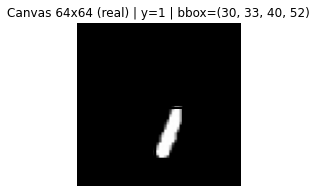

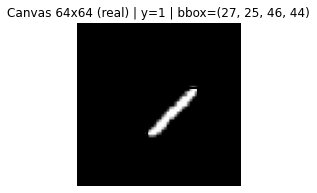

In [4]:

def paste_digit_on_canvas(digit28, canvas_size=64, min_margin=2, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)

    H = W = canvas_size
    canvas = np.zeros((H, W), dtype=np.float32)

    max_x = W - 28 - min_margin
    max_y = H - 28 - min_margin
    x0 = int(rng.integers(min_margin, max_x + 1))
    y0 = int(rng.integers(min_margin, max_y + 1))

    canvas[y0:y0+28, x0:x0+28] = np.maximum(canvas[y0:y0+28, x0:x0+28], digit28)

    bbox_local = bbox_from_threshold(digit28, thr=0.2)
    if bbox_local is None:
        bx0, by0, bx1, by1 = 0, 0, 27, 27
    else:
        bx0, by0, bx1, by1 = bbox_local

    x_min = x0 + bx0
    y_min = y0 + by0
    x_max = x0 + bx1
    y_max = y0 + by1

    return canvas, (x_min, y_min, x_max, y_max)

def make_detection_dataset(x_src, y_src, n=12000, canvas_size=64, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x_src), size=n)

    X = np.zeros((n, canvas_size, canvas_size, 1), dtype=np.float32)
    y_cls = np.zeros((n,), dtype=np.int64)
    y_box = np.zeros((n, 4), dtype=np.float32)

    for i, j in enumerate(idx):
        canvas, bbox = paste_digit_on_canvas(x_src[j], canvas_size=canvas_size, rng=rng)
        X[i, ..., 0] = canvas
        y_cls[i] = int(y_src[j])
        x_min, y_min, x_max, y_max = bbox
        y_box[i] = np.array([x_min, y_min, x_max, y_max], dtype=np.float32) / (canvas_size - 1)

    return X, y_cls, y_box

FAST_MODE = True
N = 6000 if FAST_MODE else 20000
CANVAS = 64

X, y_cls, y_box = make_detection_dataset(x_train, y_train, n=N, canvas_size=CANVAS, seed=SEED)

val_n = int(0.2 * N)
X_tr, X_va = X[:-val_n], X[-val_n:]
ytr_cls, yva_cls = y_cls[:-val_n], y_cls[-val_n:]
ytr_box, yva_box = y_box[:-val_n], y_box[-val_n:]

print("Train:", X_tr.shape, ytr_cls.shape, ytr_box.shape)
print("Val  :", X_va.shape, yva_cls.shape, yva_box.shape)

# Un par de ejemplos con bbox real
for idx in [0, 1]:
    img = X_tr[idx, ..., 0]
    cls = int(ytr_cls[idx])
    b = (ytr_box[idx] * (CANVAS-1)).astype(int)
    plot_img_with_bbox(img, tuple(b), title=f"Canvas 64x64 (real) | y={cls} | bbox={tuple(b)}")



### 3.1) Modelo: CNN con dos cabezas (clase + bbox)

**Qué haremos:** backbone convolucional + dos ramas:
- `head_cls`: softmax 10 clases
- `head_box`: regresión 4 valores (bbox normalizada)


In [5]:

def build_detector(input_shape=(64,64,1)):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)

    cls_out = layers.Dense(10, activation="softmax", name="cls")(x)
    box_out = layers.Dense(4, activation="sigmoid", name="box")(x)

    model = keras.Model(inp, outputs=[cls_out, box_out], name="mnist_detector_toy")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss={"cls": "sparse_categorical_crossentropy", "box": "mse"},
        loss_weights={"cls": 1.0, "box": 5.0},
        metrics={"cls": "accuracy"}
    )
    return model

det = build_detector((CANVAS, CANVAS, 1))
det.summary()


Model: "mnist_detector_toy"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 64, 64, 1)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 64, 64, 16)   160         ['input_1[0][0]']                
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 32, 32, 16)   0           ['conv2d[0][0]']                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 32, 32, 32)   4640        ['max_pooling2d[0][0]']          
                                                                                 

2026-03-13 15:14:53.842433: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.



### 3.2) Entrenamiento rápido + evaluación

**Qué haremos:** entrenamos pocas épocas y miramos accuracy de clasificación en validación.


Epoch 1/20
38/38 [==============================] - 37s 984ms/step - loss: 0.3368 - cls_loss: 0.3144 - box_loss: 0.0045 - cls_accuracy: 0.9117 - val_loss: 0.5243 - val_cls_loss: 0.5009 - val_box_loss: 0.0047 - val_cls_accuracy: 0.8317
Epoch 2/20
38/38 [==============================] - 4s 99ms/step - loss: 0.2628 - cls_loss: 0.2423 - box_loss: 0.0041 - cls_accuracy: 0.9321 - val_loss: 0.4491 - val_cls_loss: 0.4292 - val_box_loss: 0.0040 - val_cls_accuracy: 0.8758
Epoch 3/20
38/38 [==============================] - 3s 91ms/step - loss: 0.1840 - cls_loss: 0.1663 - box_loss: 0.0036 - cls_accuracy: 0.9548 - val_loss: 0.5227 - val_cls_loss: 0.5007 - val_box_loss: 0.0044 - val_cls_accuracy: 0.8517
Epoch 4/20
38/38 [==============================] - 3s 92ms/step - loss: 0.1519 - cls_loss: 0.1344 - box_loss: 0.0035 - cls_accuracy: 0.9652 - val_loss: 0.4050 - val_cls_loss: 0.3875 - val_box_loss: 0.0035 - val_cls_accuracy: 0.8842
Epoch 5/20
38/38 [==============================] - 3s 92ms/step -

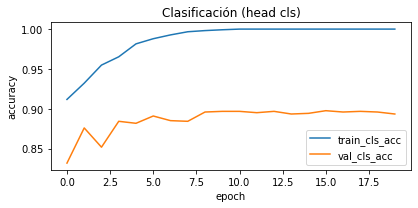

In [8]:

EPOCHS = 5 if FAST_MODE else 15
BATCH = 128

history = det.fit(
    X_tr, {"cls": ytr_cls, "box": ytr_box},
    validation_data=(X_va, {"cls": yva_cls, "box": yva_box}),
    epochs=20,
    batch_size=BATCH,
    verbose=1
)

plt.figure(figsize=(6,3))
plt.plot(history.history["cls_accuracy"], label="train_cls_acc")
plt.plot(history.history["val_cls_accuracy"], label="val_cls_acc")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.title("Clasificación (head cls)")
plt.legend(); plt.tight_layout(); plt.show()



### 3.3) Visualizar predicciones: bbox real vs bbox predicha (un par)

**Qué haremos:** mostramos 2 imágenes de validación con:
- bbox real (verde)
- bbox predicha (rojo)


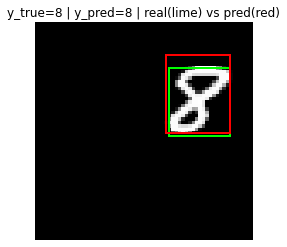

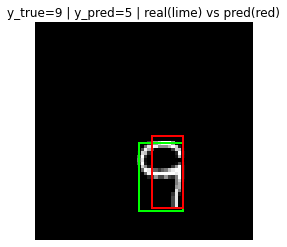

In [9]:

def plot_real_vs_pred(img, bbox_real, bbox_pred, title=None):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap="gray")
    ax = plt.gca()

    x0, y0, x1, y1 = bbox_real
    rect_r = plt.Rectangle((x0, y0), x1-x0+1, y1-y0+1, fill=False, linewidth=2, edgecolor="lime")
    ax.add_patch(rect_r)

    x0, y0, x1, y1 = bbox_pred
    rect_p = plt.Rectangle((x0, y0), x1-x0+1, y1-y0+1, fill=False, linewidth=2, edgecolor="red")
    ax.add_patch(rect_p)

    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

idxs = [0, 1]
pred_cls, pred_box = det.predict(X_va[idxs], verbose=0)

for k, idx in enumerate(idxs):
    img = X_va[idx, ..., 0]
    y_true = int(yva_cls[idx])
    y_hat = int(np.argmax(pred_cls[k]))

    b_real = (yva_box[idx] * (CANVAS-1)).astype(int)
    b_pred = (pred_box[k] * (CANVAS-1)).astype(int)

    plot_real_vs_pred(
        img,
        tuple(b_real),
        tuple(b_pred),
        title=f"y_true={y_true} | y_pred={y_hat} | real(lime) vs pred(red)"
    )



## Ideas rápidas para clase

- Sube `CANVAS` y deja más fondo vacío → detección más “real”.
- Ajusta `loss_weights` para priorizar bbox o clase.
- Ejercicio: añadir *RandomTranslation* o ruido al canvas.
